In [8]:
import sys
from pathlib import Path

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

results_dir = Path("..") / "results"
tradeoff_path = results_dir / "mnist_dp_batchsize_tradeoff.csv"
ranking_path = results_dir / "mnist_tradeoff_ranking.csv"
heatmap_path = results_dir / "mnist_tradeoff_heatmaps.png"
gradient_summary_path = results_dir / "gradient_inversion" / "batch_size_summary.csv"

In [9]:
tradeoff_df = pd.read_csv(tradeoff_path)
baseline_df = pd.read_csv(results_dir / "baseline_metrics.csv")
gradient_summary_df = pd.read_csv(gradient_summary_path)

print("Tradeoff rows:", len(tradeoff_df))
print("Baseline rows:", len(baseline_df))
print("Gradient summary rows:", len(gradient_summary_df))
tradeoff_df.head()

Tradeoff rows: 48
Baseline rows: 9
Gradient summary rows: 3


,dataset_name,model_name,activation,num_clients,clients_per_round,num_rounds,local_epochs,batch_size,client_lr,use_dp,...,attack_lr,attack_distance,secret_index,seed,noniid_alpha,secret_pos,test_loss,test_acc,attack_mse,attack_ssim
0,MNIST,LeNet,sigmoid,1,1,1,1,1,0.1,False,...,1.0,l2,7,0,NaN,0,13.228685,0.101,1.555841e-06,0.999885
1,MNIST,LeNet,sigmoid,1,1,1,1,1,0.1,False,...,1.0,l2,7,1,NaN,0,11.909290,0.101,5.756340e-07,0.999911
2,MNIST,LeNet,sigmoid,1,1,1,1,1,0.1,False,...,1.0,l2,7,2,NaN,0,12.215744,0.101,1.995473e-06,0.999847
3,MNIST,LeNet,sigmoid,1,1,1,1,1,0.1,True,...,1.0,l2,7,0,NaN,0,2.443177,0.101,5.244315e+03,-0.000014
4,MNIST,LeNet,sigmoid,1,1,1,1,1,0.1,True,...,1.0,l2,7,1,NaN,0,2.467926,0.101,5.975145e+02,-0.000091


In [10]:
summary_df = (
    tradeoff_df.groupby(["batch_size", "dp_sigma"], as_index=False)
    .agg(
        attack_ssim_mean=("attack_ssim", "mean"),
        attack_ssim_std=("attack_ssim", "std"),
        test_acc_mean=("test_acc", "mean"),
        test_acc_std=("test_acc", "std"),
    )
)
summary_df["privacy_score"] = 1 - summary_df["attack_ssim_mean"]
summary_df["tradeoff_score"] = 0.5 * summary_df["privacy_score"] + 0.5 * summary_df["test_acc_mean"]
summary_df = summary_df.sort_values(["batch_size", "dp_sigma"]).reset_index(drop=True)
summary_df

,batch_size,dp_sigma,attack_ssim_mean,attack_ssim_std,test_acc_mean,test_acc_std,privacy_score,tradeoff_score
0,1,0.00,9.998812e-01,3.220847e-05,0.101000,0.000000,0.000119,0.050559
1,1,0.01,2.192704e-03,3.889162e-03,0.101000,0.000000,0.997807,0.549404
2,1,0.05,-1.363130e-05,2.326697e-05,0.101000,0.000000,1.000014,0.550507
3,1,0.10,8.510434e-04,1.556112e-03,0.101000,0.000000,0.999149,0.550074
4,4,0.00,2.707172e-01,2.450952e-01,0.104167,0.008221,0.729283,0.416725
5,4,0.01,1.772408e-07,5.092979e-07,0.099800,0.002078,1.000000,0.549900
6,4,0.05,2.834449e-05,4.899291e-05,0.099800,0.002078,0.999972,0.549886
7,4,0.10,8.183225e-05,1.233042e-04,0.099800,0.002078,0.999918,0.549859
8,8,0.00,-8.987684e-05,7.786862e-05,0.094133,0.006363,1.000090,0.547112
9,8,0.01,-7.305230e-05,6.338346e-05,0.103033,0.009073,1.000073,0.551553


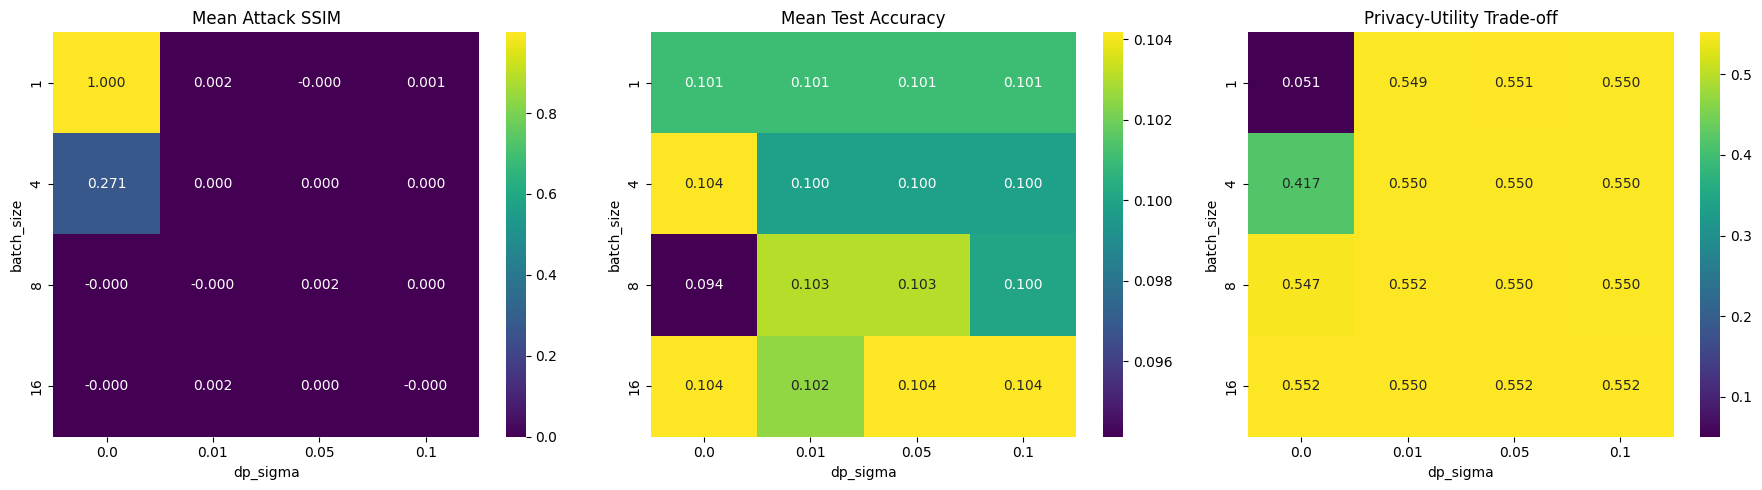

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ssim_pivot = summary_df.pivot(index="batch_size", columns="dp_sigma", values="attack_ssim_mean")
acc_pivot = summary_df.pivot(index="batch_size", columns="dp_sigma", values="test_acc_mean")
tradeoff_pivot = summary_df.pivot(index="batch_size", columns="dp_sigma", values="tradeoff_score")

sns.heatmap(ssim_pivot, annot=True, fmt=".3f", cmap="viridis", ax=axes[0])
axes[0].set_title("Mean Attack SSIM")

sns.heatmap(acc_pivot, annot=True, fmt=".3f", cmap="viridis", ax=axes[1])
axes[1].set_title("Mean Test Accuracy")

sns.heatmap(tradeoff_pivot, annot=True, fmt=".3f", cmap="viridis", ax=axes[2])
axes[2].set_title("Privacy-Utility Trade-off")

for ax in axes:
    ax.set_xlabel("dp_sigma")
    ax.set_ylabel("batch_size")

plt.tight_layout()
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.show()

In [12]:
summary_df["privacy_score"] = 1 - summary_df["attack_ssim_mean"]

summary_df["tradeoff_score"] = (
    0.5 * summary_df["privacy_score"] +
    0.5 * summary_df["test_acc_mean"]
)


In [13]:
ranking_df = summary_df.sort_values("tradeoff_score", ascending=False).reset_index(drop=True)
ranking_path = results_dir / "mnist_tradeoff_ranking.csv"
ranking_df.to_csv(ranking_path, index=False)

print("Top configurations by trade-off score:")
display(ranking_df[[
    "batch_size",
    "dp_sigma",
    "attack_ssim_mean",
    "test_acc_mean",
    "privacy_score",
    "tradeoff_score"
]].head(10))


NameError: name 'os' is not defined

In [ ]:
ssim_pivot = summary_df.pivot(index="batch_size", columns="dp_sigma", values="attack_ssim_mean")
acc_pivot = summary_df.pivot(index="batch_size", columns="dp_sigma", values="test_acc_mean")
tradeoff_pivot = summary_df.pivot(index="batch_size", columns="dp_sigma", values="tradeoff_score")

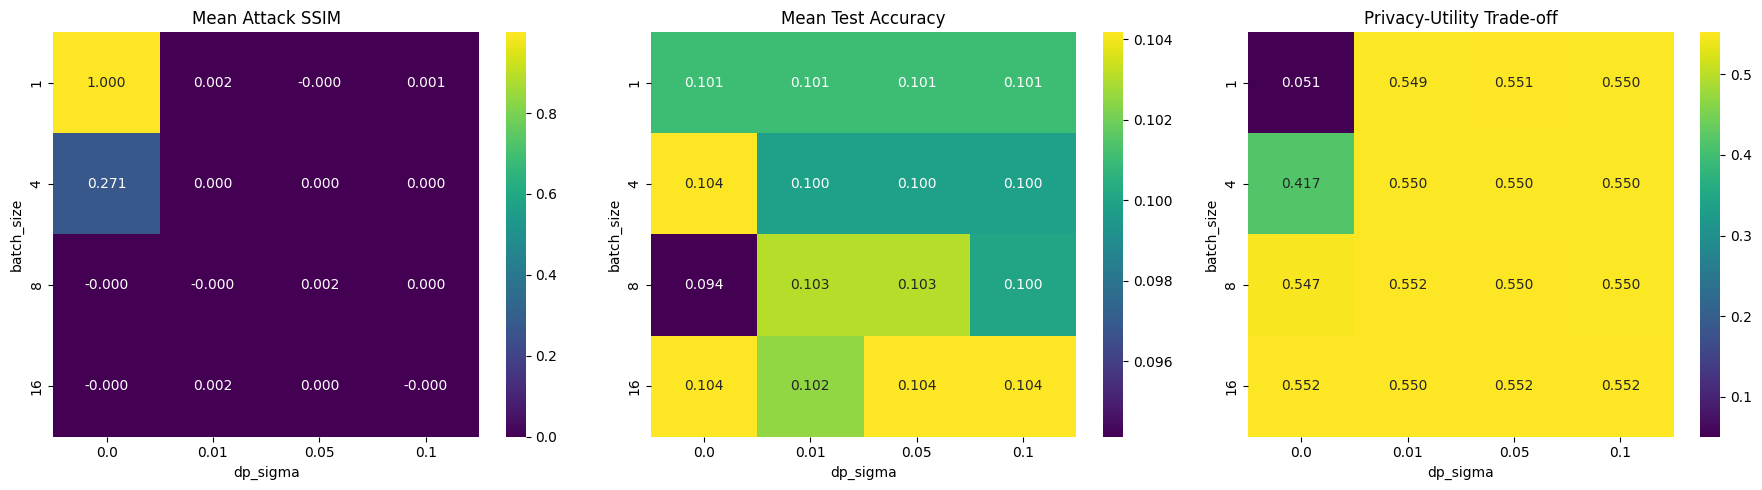

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(ssim_pivot, annot=True, fmt=".3f", cmap="viridis", ax=axes[0])
axes[0].set_title("Mean Attack SSIM")

sns.heatmap(acc_pivot, annot=True, fmt=".3f", cmap="viridis", ax=axes[1])
axes[1].set_title("Mean Test Accuracy")

sns.heatmap(tradeoff_pivot, annot=True, fmt=".3f", cmap="viridis", ax=axes[2])
axes[2].set_title("Privacy-Utility Trade-off")

for ax in axes:
    ax.set_xlabel("dp_sigma")
    ax.set_ylabel("batch_size")

plt.tight_layout()

In [ ]:
plot_path = results_dir / "mnist_tradeoff_heatmaps.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved ranking to: {ranking_path}")
print(f"Saved figure to: {plot_path}")

<Figure size 640x480 with 0 Axes>

Saved ranking to: ../results/mnist_tradeoff_ranking.csv
Saved figure to: ../results/mnist_tradeoff_heatmaps.png
